<a href="https://colab.research.google.com/github/viniciusarnom/estudo_dirigido/blob/main/Importa%C3%A7%C3%A3o%20Total%20incluindo%20arquivo%20CSV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Arquivo binário concatenado salvo! Total de amostras: 15000000
Features salvas no arquivo 'concatenated_features.csv'!
Valores da primeira linha:
Label        0.000000
I           -0.001282
Q           -0.007569
Magnitude    0.007676
Spectrum     1.127320
Name: 0, dtype: float64


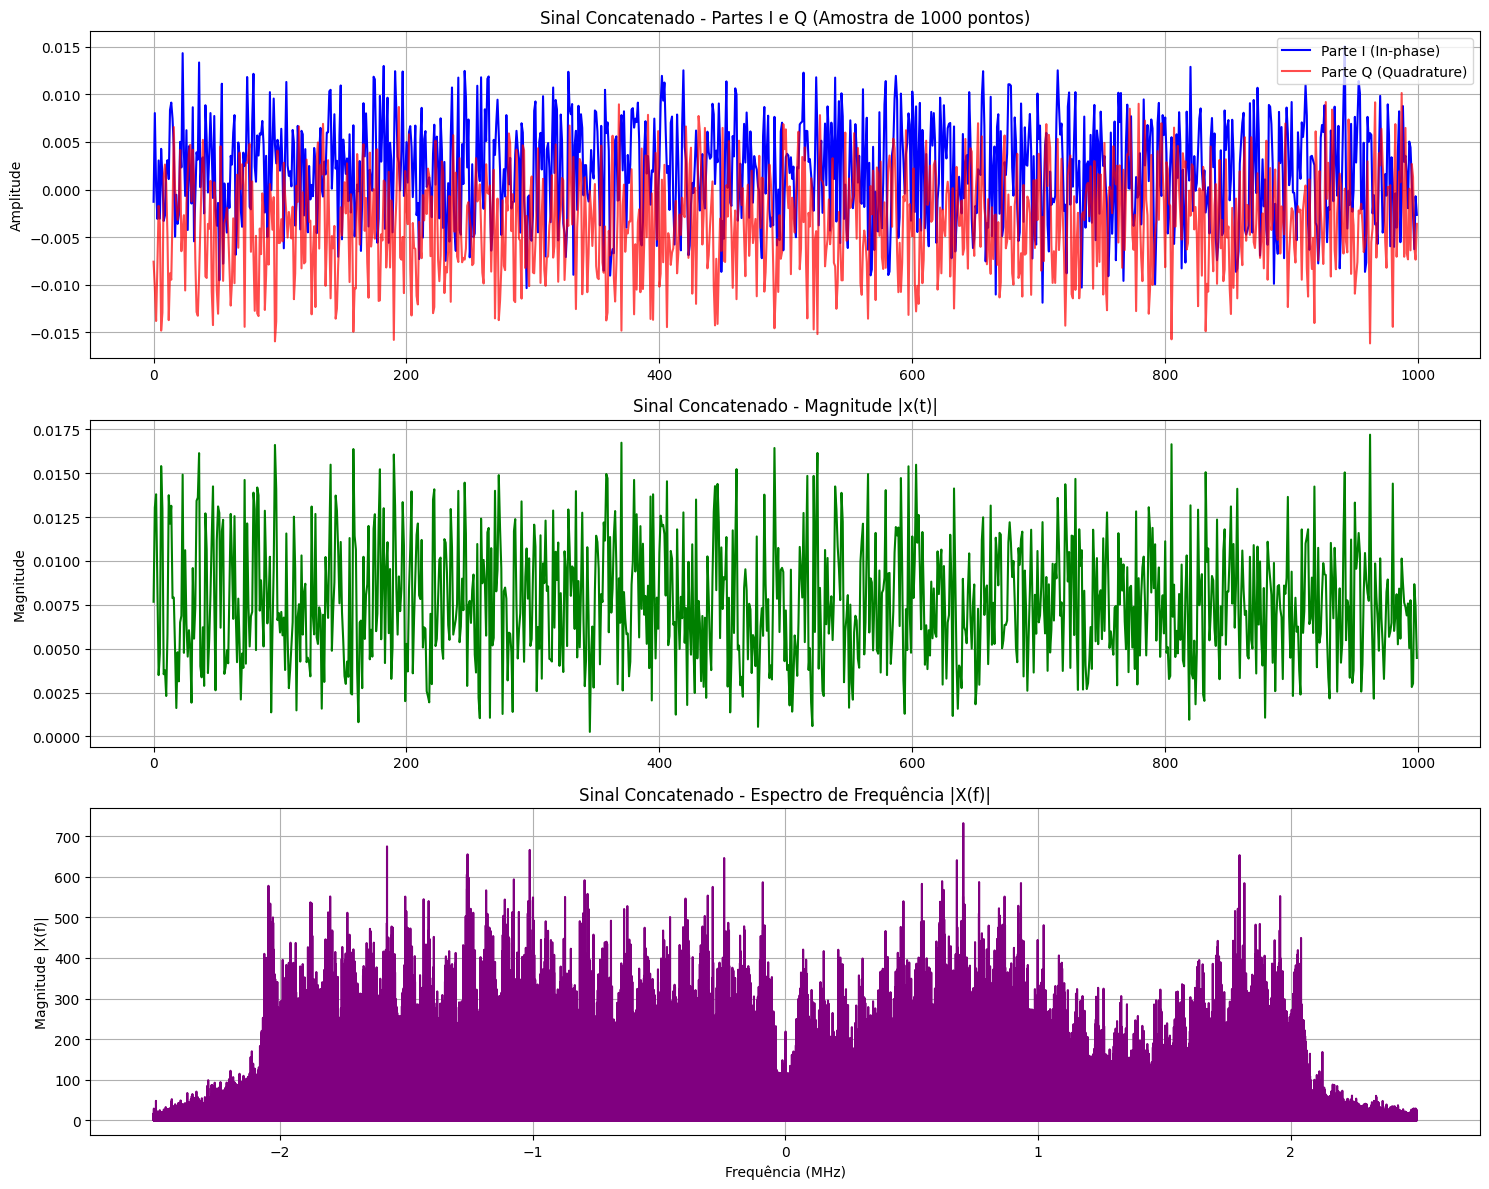

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Definir os arquivos que serão concatenados
files = [
    'WiFi_Day_1_browning_s1.bin',
    'WiFi_Day_1_browning_s2.bin',
    'WiFi_Day_1_browning_s3.bin',
    'WiFi_Day_1_browning_s4.bin',
    'WiFi_Day_1_browning_s5.bin'
]

# 2. Ler os dados (5.000 amostras de cada arquivo)
all_data = []
for f in files:
    data = np.fromfile(f, dtype=np.complex64)
    all_data.append(data)

# 3. Concatenar todos os arrays em um só (Total: 25.000 amostras)
concat_data = np.concatenate(all_data)

# 4. Salvar o sinal concatenado em um único arquivo .bin
concat_data.tofile('concatenated_browning_day1.bin')
print(f"Arquivo binário concatenado salvo! Total de amostras: {len(concat_data)}")

# 5. Extrair as features
I = np.real(concat_data)
Q = np.imag(concat_data)
Magnitude = np.abs(concat_data)

# Calcular o espectro de frequência
X_f = np.fft.fft(concat_data)
Spectrum = np.abs(np.fft.fftshift(X_f))

# 6. Criar o DataFrame (tabela) com as features e a label = 0
df = pd.DataFrame({
    'Label': 0,
    'I': I,
    'Q': Q,
    'Magnitude': Magnitude,
    'Spectrum': Spectrum
})

# Salvar as features para um arquivo CSV para Machine Learning
df.to_csv('concatenated_features.csv', index=False)
print("Features salvas no arquivo 'concatenated_features.csv'!")

# 7. Criar os gráficos solicitados
fs = 5e6 # Taxa de amostragem
freqs = np.fft.fftshift(np.fft.fftfreq(len(concat_data), 1/fs))

plt.figure(figsize=(15, 12))

# Subplot 1: I e Q (Mostrando as primeiras 1000 amostras para legibilidade)
plt.subplot(3, 1, 1)
plt.plot(I[:1000], label='Parte I (In-phase)', color='blue')
plt.plot(Q[:1000], label='Parte Q (Quadrature)', color='red', alpha=0.7)
plt.title('Sinal Concatenado - Partes I e Q (Amostra de 1000 pontos)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Subplot 2: Magnitude
plt.subplot(3, 1, 2)
plt.plot(Magnitude[:1000], color='green')
plt.title('Sinal Concatenado - Magnitude |x(t)|')
plt.ylabel('Magnitude')
plt.grid(True)

# Subplot 3: Espectro de Frequência do sinal inteiro
plt.subplot(3, 1, 3)
plt.plot(freqs / 1e6, Spectrum, color='purple')
plt.title('Sinal Concatenado - Espectro de Frequência |X(f)|')
plt.xlabel('Frequência (MHz)')
plt.ylabel('Magnitude |X(f)|')
plt.grid(True)

plt.tight_layout()
plt.savefig('concatenated_plots.png')

# 1. Carregar o arquivo CSV que contém todas as features
df = pd.read_csv('concatenated_features.csv')

# 2. Exibir a primeira linha (o Pandas usa o índice 0 para a primeira linha)
primeira_linha = df.iloc[0]

print("Valores da primeira linha:")
print(primeira_linha)

